In [1]:
import pandas as pd

In [2]:
df=pd.read_csv('/content/drive/MyDrive/Telco-Customer-Churn.csv')

OVERVIEW DATASET
1. CustomerID : ID unik setiap pelanggan
2. gender : Jenis Kelamin pelanggan (female,male)
3. SeniorCitizen : pelanggan lanjut usia (yes.no)
4. Partner : status pernikahan (yes,no)
5. Dependents : menunjukkan pelanggan memiliki tanggung jawab (yes,no)
6. tenure : lama pelanggan berlangganan selama satuan bulan
7. PhoneService : menunjukan apakah pelanggan menggunakan layanan telepon (yes,no)
8. MultipleLines : apakah pelanggan memiliki beberaoa saluran atau tidak (yes,no,tidak ada layanan telepon)
9. InternetServuce : penyediaan layanan internet pelanggan (DSL, optic fiber, no)
10. OnlineSecurity : apakah pelanggan memiliki online security atau tidak (yes,no, no internet service)
11. OnlienBackup : apakah pelanggan memiliki online backup atau tidak (yes,no,no internet service)
12. DeviceProtection :apakah pelanggan memiliki protection device (yes,no,no internet service)
13. TechSupport : apakah pelanggan memiliki tech support atau tidak (yes,no, no internet service)
14. StreamingTV : apakah pelanggan memiliki streaming TV atau tidak (yes,no,no internet service)
15. StreamingMovies : apakah pelanggan memiliki streaming movie atau tidak (yes,no,no internet service)
16. contract : jangka waktu kontrak pelanggan (month-to-month, one year, two year)
17. PaperlessBilling : apakah pelanggan memiliki paperless billing atau tidak (yes,no)
18. PaymentMethod : metode pembayaran pelanggan (Electronic check, Mailed check, Bank transfer (automatic), Credit card)
19. MonthlyCharges : Jumlah yang dibebankan kepada pelanggan setiap bulan
20. TotalCharges : Jumlah total yang dibebankan kepada pelanggan
21. Churn : apakah pelanggan Churn atau tidak (yes,no)


In [3]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [4]:
df.shape

(7043, 21)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [6]:
df["TotalCharges"].head()

,TotalCharges
0,29.85
1,1889.5
2,108.15
3,1840.75
4,151.65


In [7]:
#mengubah tipe data TotalCharges ke numeric
df["TotalCharges"]=df["TotalCharges"].str.strip() #menghapus spasi
df["TotalCharges"]= pd.to_numeric(df["TotalCharges"],errors="coerce") #mengubah ke numeric

In [8]:
#ccek jumlah NaN pada kolom TotalCharges
df["TotalCharges"].isnull().sum()

np.int64(11)

In [9]:
#meihat baris yang NaN
df[df["TotalCharges"].isnull()][["customerID","tenure","MonthlyCharges","TotalCharges"]]

,customerID,tenure,MonthlyCharges,TotalCharges
488,4472-LVYGI,0,52.55,NaN
753,3115-CZMZD,0,20.25,NaN
936,5709-LVOEQ,0,80.85,NaN
1082,4367-NUYAO,0,25.75,NaN
1340,1371-DWPAZ,0,56.05,NaN
3331,7644-OMVMY,0,19.85,NaN
3826,3213-VVOLG,0,25.35,NaN
4380,2520-SGTTA,0,20.00,NaN
5218,2923-ARZLG,0,19.70,NaN
6670,4075-WKNIU,0,73.35,NaN


In [10]:
#handle missing
df=df.dropna(subset=["TotalCharges"])

In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7032 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7032 non-null   object 
 1   gender            7032 non-null   object 
 2   SeniorCitizen     7032 non-null   int64  
 3   Partner           7032 non-null   object 
 4   Dependents        7032 non-null   object 
 5   tenure            7032 non-null   int64  
 6   PhoneService      7032 non-null   object 
 7   MultipleLines     7032 non-null   object 
 8   InternetService   7032 non-null   object 
 9   OnlineSecurity    7032 non-null   object 
 10  OnlineBackup      7032 non-null   object 
 11  DeviceProtection  7032 non-null   object 
 12  TechSupport       7032 non-null   object 
 13  StreamingTV       7032 non-null   object 
 14  StreamingMovies   7032 non-null   object 
 15  Contract          7032 non-null   object 
 16  PaperlessBilling  7032 non-null   object 
 17  

In [12]:
df["TotalCharges"].dtype

dtype('float64')

In [13]:
df["Churn"].value_counts()

,count
Churn,
No,5163
Yes,1869


In [14]:
df["Churn"].value_counts(normalize=True)*100

,proportion
Churn,
No,73.421502
Yes,26.578498


In [15]:
df.groupby("Churn")["tenure"].agg(["mean","median","min","max"])

,mean,median,min,max
Churn,,,,
No,37.650010,38.0,1,72
Yes,17.979133,10.0,1,72


hasil analisis menunjukkan bahwa pelanggan yang churn cenderung emiliki masa berlangganan lebih pendek dibanding pelanggan yang bertahan. median tenure pelanggan churn hanya sekitar 10 bulan, sedangkan pelanggan yang tidak churn mencapai 38 bulan. yang artinya churn paling banyak tejadi pada pelanggan baru, terutama di tahun pertama berlangganan

In [16]:
#MonthlyCharges berdasarkan Churn
df.groupby("Churn")["MonthlyCharges"].agg(["mean","median","min","max"])

,mean,median,min,max
Churn,,,,
No,61.307408,64.45,18.25,118.75
Yes,74.441332,79.65,18.85,118.35


pelanggab yang churn mmemiliki biaya bulanan lebih tinggi dibanding pelanggan yang bertahan. rata-rata MonthlyCharges pelanggan churn adalah sekitar 74.44, sedangkan peanggan non-churn hanya sekitar 61.31. dari analisis tersebut semakin mahal biaya langanan per bulan, semin besar kemungkinan pelangga untuk berhenti berlangganan

In [17]:
#Churn Rate per contract
df.groupby("Contract")["Churn"].value_counts(normalize=True)*100

Contract        Churn
Month-to-month  No       57.290323
                Yes      42.709677
One year        No       88.722826
                Yes      11.277174
Two year        No       97.151335
                Yes       2.848665
Name: proportion, dtype: float64

pelanggan dengan jontra month-to-month memiliki churn rae paling tinggi yaitu 42.7%. sebaiknya churn  jauh lebih redah pada pelanggan dengan konntrak jangka panjanng yang hanya 11.3% untuk satu tahun dan untuk kontra 2 tahun 2.8%. maka semakin tinggi panjang kontrak, semakin kecil kemungkinan pelanggan untuk churn.

In [18]:
#churn rate per payment method
df.groupby("PaymentMethod")["Churn"].value_counts(normalize=True)*100

PaymentMethod              Churn
Bank transfer (automatic)  No       83.268482
                           Yes      16.731518
Credit card (automatic)    No       84.746877
                           Yes      15.253123
Electronic check           No       54.714588
                           Yes      45.285412
Mailed check               No       80.798005
                           Yes      19.201995
Name: proportion, dtype: float64

pelanggan yang menggunakan electronic check memiliki rate paling tinggi sampai sekitar 45.3%, dibandingkan dengan pembayaran otomais seperti card credit 15.3% atau bank tranfer 16.7%. metode pembayaran manual, khususnya electronic check mempengaruhi resiko churn yang lebih tinggi

In [19]:
#churn rate berdasarkan onlinesecurity
df.groupby("OnlineSecurity")["Churn"].value_counts(normalize=True)*100

OnlineSecurity       Churn
No                   No       58.221333
                     Yes      41.778667
No internet service  No       92.565789
                     Yes       7.434211
Yes                  No       85.359801
                     Yes      14.640199
Name: proportion, dtype: float64

layanan tambahan seperti OnlineSecurity dapat meningkatkan loyalitas pelanggan dan menurnkan resiko churn karena, pelangan yang tidak memiliki onlinesecurity menunjukkan rate paling tinggi yaitu sekitar 41,8% da pelanggan yang memiliki hanya churn sekitar 14.6%

In [20]:
#churn berdaarkan TechSupport
df.groupby("TechSupport")["Churn"].value_counts(normalize=True) * 100

TechSupport          Churn
No                   No       58.352535
                     Yes      41.647465
No internet service  No       92.565789
                     Yes       7.434211
Yes                  No       84.803922
                     Yes      15.196078
Name: proportion, dtype: float64

layanan dukungan teknis berperanpenting dalam meningkatka retensi dan menurnkan risiko churn karena yang tidak memiliki TechSupport memiliki churn rate tinggi sekitar 41.6% sedangkan pelanggan yang memilikinya hanya churn sekitar 15.2%

In [21]:
#chunr berdasarkan intenetservice
df.groupby("InternetService")["Churn"].value_counts(normalize=True) * 100

InternetService  Churn
DSL              No       81.001656
                 Yes      18.998344
Fiber optic      No       58.107235
                 Yes      41.892765
No               No       92.565789
                 Yes       7.434211
Name: proportion, dtype: float64

pelangan dengan Fiber Optic beriisko churn karena memiliki rate paling tinggi sekitar 41.9% jauh dibanding pelanggan DSL yang 19.0% atau pelanggan tanpa layanan internet yang hanya 7.4%

In [22]:
# churn berdaarkan PaperlessBillling
df.groupby("PaperlessBilling")["Churn"].value_counts(normalize=True)*100

PaperlessBilling  Churn
No                No       83.624302
                  Yes      16.375698
Yes               No       66.410749
                  Yes      33.589251
Name: proportion, dtype: float64

pelanggan yang menggunakan PaperlessBilling (tagihan digital) memiliki chur yang tinggi sekitar 33.6%, dibanding pelanggan yang menggunakan paperless billig yang hanya 16.4%. pelanggan dengan sistem tagihan digital cenderung lebih beresiko churn, kemungkinan mereka lebih aktif secara oline dan mudah berpidah layanan

In [23]:
#churn berdasarkan Petner
df.groupby("Partner")["Churn"].value_counts(normalize=True)*100

Partner  Churn
No       No       67.023908
         Yes      32.976092
Yes      No       80.282935
         Yes      19.717065
Name: proportion, dtype: float64

pelanggan yang tidak memiliki patner mmeiliki churn rate yang lebih tinggi sekitar 33.0% dibanding yang memiliki partner yang hanya 19.7%. ini menunjukan berarti pelanggan dengan psangan cenderung lebih loyal da stabil dalam berlangganan

In [24]:
#churn berdasarkan dependent
df.groupby("Dependents")["Churn"].value_counts(normalize=True)*100

Dependents  Churn
No          No       68.720860
            Yes      31.279140
Yes         No       84.468795
            Yes      15.531205
Name: proportion, dtype: float64

pelangga yang tidak memiliki tanggungan memiliki churn rate seitar 31.3%. sedangkan pelanggan yang emiliki tanggungan jauh lebih rendah hanya 15.5%. pelanggan dengan tanggungan lebih bertahan kerana kebutuhan layanan yang lebih konsisten

In [25]:
seg1=df[
    (df['Contract']=="Month-to-month")&
    (df["tenure"]>12)
]
seg1.shape
seg1["Churn"].value_counts(normalize=True)*100

,proportion
Churn,
No,66.454014
Yes,33.545986


pelanggan dengan ontrak month-to-month yang masih baru (tenure <12 bulan) memiliki churn rate 33.5% lebih tingggi dibanding churn baseline keselurhan 26.6%. ini menunjukkan bahwa pelanggan baru dengan kontrak bulanan merpakan segmen yang lebih berisiko untuk churn dan perlu menjadi prioritas utama dalam strategi awal

In [26]:
seg2=df[
    (df["Contract"]=="Month-to-month")&
    (df["PaymentMethod"]=="Electronic check")&
    (df["tenure"]<12)
]
seg2.shape
seg2["Churn"].value_counts(normalize=True)*100

,proportion
Churn,
Yes,63.904035
No,36.095965


pelanggan baru (tenure <12 bulan) dengan kontrak month-to-month an metode pembayaran electronic check memiliki churn rate sangat tinggi yaitu 63.9%. auh elebih besar dibanding churn baseline 26.6%  sehingga  segmen ini merupakan elompok pelanggan dengan resiko churn palng kritis dan perlu menjadi prioritas utama dalam progra retensi

In [27]:
seg3=df[
    (df["Contract"]=="Month-to-month")&
    (df["PaymentMethod"]=="Electronic check")&
    (df["OnlineSecurity"]=="No")&
    (df["tenure"]<12)
]
seg3.shape
seg3["Churn"].value_counts(normalize=True)*100

,proportion
Churn,
Yes,67.72554
No,32.27446


pelanggan baru dengan kontrak month-to-month, metode pembayaran electronic check, dn tidk memiliki onlinesecurity memiliki churn rate sangat tinggi sekkitar 67.7%. kombinasi ini menunjukkan kelompok pelanggan dengan resiko churn paling ekstrem dan menjadi target utama untuk program retensi penawaran keamanan tambahan atau kontrak janga panjang

In [28]:
seg4 = df[
    (df["Contract"] == "Month-to-month") &
    (df["PaymentMethod"] == "Electronic check") &
    (df["OnlineSecurity"] == "No") &
    (df["TechSupport"] == "No") &
    (df["tenure"] < 12)
]

seg4.shape
seg4["Churn"].value_counts(normalize=True) * 100


,proportion
Churn,
Yes,70.422535
No,29.577465


In [29]:
def churn_rate_table(column):
  table=(
      df.groupby(column)["Churn"]
      .value_counts(normalize=True)
      .rename("proportion")
      .reset_index()
  )

  table=table[table["Churn"]=="Yes"]
  table["proportion"]=table["proportion"]*100
  return table.sort_values("proportion",ascending=False)

In [30]:
#contract churn rate summary
churn_rate_table("Contract")

,Contract,Churn,proportion
1,Month-to-month,Yes,42.709677
3,One year,Yes,11.277174
5,Two year,Yes,2.848665


pelanggan dengan kontrak month-to-month memiliki churn rate tertinggi yaitu 42.7%, sedangkan one year hanya 11.3% dan kontrak to year paling stabil dengan 2.8%. yang artinya semakin panjang kontrak pelangan, semakin kecil kemungkinan mereka churn

In [31]:
#paymentmethod churn rate summary
churn_rate_table("PaymentMethod")

,PaymentMethod,Churn,proportion
5,Electronic check,Yes,45.285412
7,Mailed check,Yes,19.201995
1,Bank transfer (automatic),Yes,16.731518
3,Credit card (automatic),Yes,15.253123


pelanggan yang menggunakan electric check memiliki rate tertinggi yaitu 45.3% sedangkan metode lain seperti mailed check 19.2%, bank tranfer 16.7% dan credit card otomatis 15.3%. pelanggan dengan pembayaran manual, teutama electronic check memiliki resiko churn paing tinggi

In [32]:
#InternetService churn rate summary
churn_rate_table("InternetService")

,InternetService,Churn,proportion
3,Fiber optic,Yes,41.892765
1,DSL,Yes,18.998344
5,No,Yes,7.434211


pelanggan dengan layanan Fiber optic memiliki churn rate tertinggi merupakan segmen beresiko tinggi yaitu 41.9% berbeda dengan DSL lebih rendah dengan 19.0% dan pelanggan tanpa layanan internet memiliki churn paling rendah yaitu hanya 7.4%.

In [33]:
#OnlineSecurity churn rate summmary
churn_rate_table("OnlineSecurity")

,OnlineSecurity,Churn,proportion
1,No,Yes,41.778667
5,Yes,Yes,14.640199
3,No internet service,Yes,7.434211


pelanggan yang tidak memiliki onlinesecurity memiliki churn rate sangat tinggi yaitu 41.8%, sedangkan yang memiliki onlinesecurity hanya 14.6% dan pelanggan tanpa layanan internet churn rate paling kecil yaitu 7.4%. ketiadaan fitur onlinesecurity merupakan salah satu indikator terbesar pelanggan berpotensi churn

In [34]:
df["RiskSegment"] = "Normal"

df.loc[
    (df["Contract"] == "Month-to-month") &
    (df["PaymentMethod"] == "Electronic check") &
    (df["InternetService"] == "Fiber optic") &
    (df["OnlineSecurity"] == "No"),
    "RiskSegment"
] = "High Risk"

df["RiskSegment"].value_counts()


,count
RiskSegment,
Normal,5904
High Risk,1128


sebanyak 1128 pelanggan masuk kategori high risk, sedangkan 5904 pelanggan berada pada kategori normal. sekitar 16% pelanggan memiliki karakteristik yang membuat mereka lebih rentan churn

In [35]:
#churn rate per segemen
df.groupby("RiskSegment")["Churn"].value_counts(normalize=True) * 100

RiskSegment  Churn
High Risk    Yes      63.475177
             No       36.524823
Normal       No       80.470867
             Yes      19.529133
Name: proportion, dtype: float64

Segmen **High Risk** dan **Normal** sama-sama berisi pelanggan yang bisa mengalami churn, namun perbedaannya terletak pada tingkat risikonya. Pelanggan dalam kategori **High Risk** adalah mereka yang memiliki karakteristik yang sering ditemukan pada pelanggan yang berhenti berlangganan, sehingga peluang churn mereka jauh lebih besar. Hal ini terbukti dari output bahwa sekitar **63% pelanggan High Risk benar-benar churn**. Sementara itu, pelanggan dalam segmen **Normal** memiliki risiko churn lebih rendah karena tidak memiliki kombinasi faktor tersebut, sehingga hanya sekitar **19% yang churn**.

In [47]:
baseline_churn = df["Churn"].value_counts(normalize=True)["Yes"] * 100
highrisk_churn = df.groupby("RiskSegment")["Churn"].value_counts(normalize=True)["High Risk"]["Yes"] * 100

print(f"Baseline churn rate: {baseline_churn:.2f}%")
print(f"High Risk churn rate: {highrisk_churn:.2f}%")


Baseline churn rate: 26.58%
High Risk churn rate: 63.48%


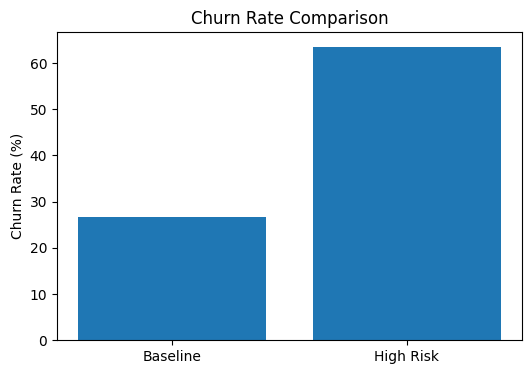

In [37]:
import matplotlib.pyplot as plt

# Hitung churn rate
baseline = df["Churn"].value_counts(normalize=True)["Yes"] * 100
highrisk = df.groupby("RiskSegment")["Churn"].value_counts(normalize=True)["High Risk"]["Yes"] * 100

# plot data
rates = [baseline, highrisk]
labels = ["Baseline", "High Risk"]

# Plot
plt.figure(figsize=(6,4))
plt.bar(labels, rates)

plt.title("Churn Rate Comparison")
plt.ylabel("Churn Rate (%)")
plt.show()


pada grafik di atas menunjukkan bahwa churn pada segmen high risk jauh lebih tinggi dibanding baseline

In [50]:
#faktor penyebeb churn tertinggi
churn_contract = df.groupby("Contract")["Churn"].value_counts(normalize=True).unstack()["Yes"] * 100
churn_payment = df.groupby("PaymentMethod")["Churn"].value_counts(normalize=True).unstack()["Yes"] * 100
churn_internet = df.groupby("InternetService")["Churn"].value_counts(normalize=True).unstack()["Yes"] * 100
churn_Security = df.groupby("OnlineSecurity")["Churn"].value_counts(normalize=True).unstack()["Yes"] * 100

display(churn_contract.sort_values(ascending=False))
display(churn_payment.sort_values(ascending=False))
display(churn_internet.sort_values(ascending=False))
display(churn_Security.sort_values(ascending=False))


,Yes
Contract,
Month-to-month,42.709677
One year,11.277174
Two year,2.848665


,Yes
PaymentMethod,
Electronic check,45.285412
Mailed check,19.201995
Bank transfer (automatic),16.731518
Credit card (automatic),15.253123


,Yes
InternetService,
Fiber optic,41.892765
DSL,18.998344
No,7.434211


,Yes
OnlineSecurity,
No,41.778667
Yes,14.640199
No internet service,7.434211


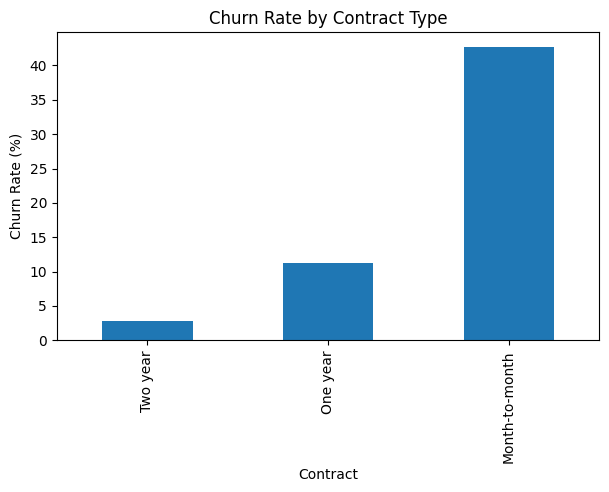

In [43]:
contract_churn = (
    df.groupby("Contract")["Churn"]
    .value_counts(normalize=True)
    .unstack()["Yes"] * 100
)

plt.figure(figsize=(7,4))
contract_churn.sort_values().plot(kind="bar")

plt.title("Churn Rate by Contract Type")
plt.ylabel("Churn Rate (%)")
plt.show()


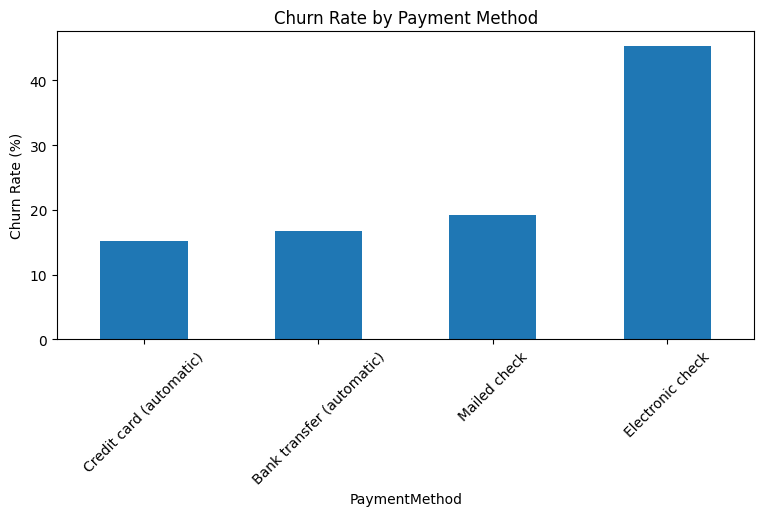

In [44]:
payment_churn = (
    df.groupby("PaymentMethod")["Churn"]
    .value_counts(normalize=True)
    .unstack()["Yes"] * 100
)

plt.figure(figsize=(9,4))
payment_churn.sort_values().plot(kind="bar")

plt.title("Churn Rate by Payment Method")
plt.ylabel("Churn Rate (%)")
plt.xticks(rotation=45)
plt.show()


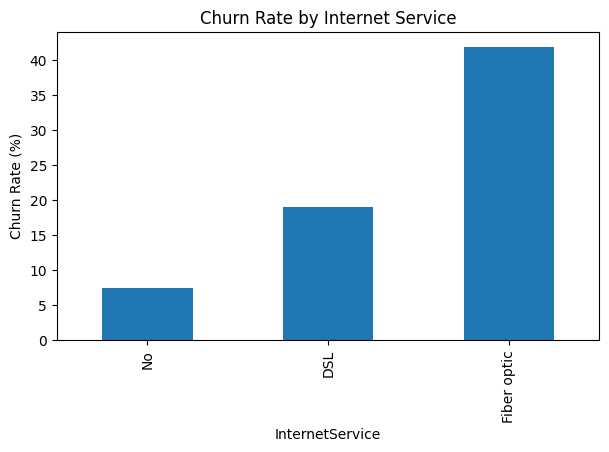

In [45]:
internet_churn = (
    df.groupby("InternetService")["Churn"]
    .value_counts(normalize=True)
    .unstack()["Yes"] * 100
)

plt.figure(figsize=(7,4))
internet_churn.sort_values().plot(kind="bar")

plt.title("Churn Rate by Internet Service")
plt.ylabel("Churn Rate (%)")
plt.show()


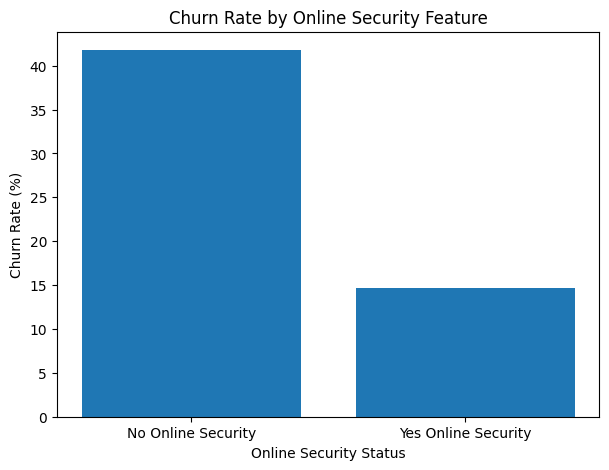

In [53]:
# Churn rate OnlineSecurity
online_security_rate = {
    "No Online Security": 41.78,
    "Yes Online Security": 14.64
}

plt.figure(figsize=(7,5))
plt.bar(online_security_rate.keys(), online_security_rate.values())

plt.title("Churn Rate by Online Security Feature")
plt.ylabel("Churn Rate (%)")
plt.xlabel("Online Security Status")

plt.show()


pelanggan tanpa fitur keamanan online hampir 3 kali lebuh rentan churn dibanding pelanggan yang memiliki layanan tersebut

In [54]:
#identifikasi segmen dengan churn rate tertinggi
top_segments = (
    df.groupby(["Contract", "PaymentMethod", "InternetService","OnlineSecurity"])["Churn"]
    .value_counts(normalize=True)
    .unstack()["Yes"]
    .sort_values(ascending=False)
    .head(5) * 100
)

top_segments


Contract        PaymentMethod              InternetService  OnlineSecurity
Month-to-month  Electronic check           Fiber optic      No                63.475177
                Mailed check               Fiber optic      No                54.938272
                Bank transfer (automatic)  Fiber optic      No                48.616601
                Credit card (automatic)    Fiber optic      No                44.588745
                Electronic check           DSL              No                43.490305
Name: Yes, dtype: float64

pelanggan dengan kontrak fleksibel, pembayaran non-otomatis, layanan fiber optiv dan tanpa fitur keamanan online merupakan segemn paling berisiko

In [55]:
recommendations = pd.DataFrame({
    "Faktor Churn": [
        "Month-to-month contract",
        "Electronic check payment",
        "No OnlineSecurity",
        "Fiber optic service",
        "High Risk segment"
    ],
    "Churn Risk": [
        "High",
        "Very High",
        "High",
        "High",
        "Extreme"
    ],
    "Business Recommendation": [
        "berikan promo kontrak tahunan ",
        "tawarkan ke pembayaran otomatis",
        "berikan trial keamanan gratis",
        "tingkatkan kualitas dan harga paket",
        "prioritas program retensi khusus"
    ]
})

recommendations


,Faktor Churn,Churn Risk,Business Recommendation
0,Month-to-month contract,High,berikan promo kontrak tahunan
1,Electronic check payment,Very High,tawarkan ke pembayaran otomatis
2,No OnlineSecurity,High,berikan trial keamanan gratis
3,Fiber optic service,High,tingkatkan kualitas dan harga paket
4,High Risk segment,Extreme,prioritas program retensi khusus


KESIMPULAN :
berdasarkan hasil analisis Customer Churn pada dataset Telco Customer Churn, diperoleh baseline churn rate sebesar 26.6%, yang menunjukkan bahwa sekitar seperempat pelanggan dalam dataset berhenti berlangganan. Namun, setelah dilakukan eksplorasi lebih lanjut, churn tidak terjadi secara acak melainkan terkonsentrasi pada kelompok pelanggan tertentu. Pelanggan yang churn umumnya memiliki masa berlangganan lebih singkat (tenure rendah) serta membayar biaya bulanan lebih tinggi dibanding pelanggan yang bertahan. Faktor layanan yang paling berkontribusi terhadap churn adalah kontrak month-to-month, metode pembayaran electronic check, penggunaan internet fiber optic, serta pelanggan yang tidak memiliki fitur OnlineSecurity. Ketika faktor-faktor tersebut digabungkan dalam segmentasi High Risk, churn rate meningkat drastis hingga mencapai lebih dari 63%, jauh di atas baseline. Hal ini menegaskan bahwa perusahaan perlu memprioritaskan strategi retensi pada segmen pelanggan berisiko tinggi melalui promo kontrak jangka panjang, migrasi pembayaran otomatis, peningkatan kualitas layanan fiber optic, serta bundling layanan keamanan online untuk menekan churn secara lebih efektif.